MMSI     = Ship ID
timestamp= When/where ship broadcast
lat      = Latitude
lon      = Longitude
sog      = Speed Over Ground

Query list for the demo:

*   What is the name of ship MMSI 671087100?
*  How many ships are in the dataset?
*   What is the last known location of ship MMSI 671087100?
*   Which other ships did MMSI 671087100 get close to (70m)?
*   How long did ship MMSI 671087100 stay at sea?










In [77]:
# Import data
import pandas as pd
import numpy as np
import os

input_file_path = '/content/ais-2025-01-01'
full_df = pd.read_csv(input_file_path)
full_df['base_date_time'] = pd.to_datetime(full_df['base_date_time'], errors='coerce')

In [78]:
print(full_df.head)

<bound method NDFrame.head of               mmsi      base_date_time  longitude  latitude  sog    cog  \
0        671087100 2025-01-01 00:00:00  -66.10297  18.46281  0.0  176.7   
1        367733950 2025-01-01 00:00:00 -122.60927  48.48503  0.0  215.5   
2        368138010 2025-01-01 00:00:02  -73.84652  40.47715  5.5  286.9   
3        367637210 2025-01-01 00:00:03  -90.21215  29.12033  0.0  227.6   
4        368050000 2025-01-01 00:00:03  -72.46934  41.27196  0.0  107.1   
...            ...                 ...        ...       ...  ...    ...   
7337203  367619000 2025-01-01 23:25:06  144.43231  13.48371  5.3   18.3   
7337204  338926443 2025-01-01 23:41:09  144.66405  13.42325  0.0    0.0   
7337205  338926443 2025-01-01 23:47:10  144.66403  13.42323  0.0    0.0   
7337206  367619000 2025-01-01 23:57:37  144.44851  13.53139  5.5   19.6   
7337207  338926443 2025-01-01 23:50:09  144.66405  13.42322  0.0    0.0   

         heading         vessel_name         imo call_sign  vessel_ty

In [79]:


# Drop rows where base_date_time conversion failed, as these are critical for time-based analysis
full_df = full_df.dropna(subset=['base_date_time'])

# Get all unique MMSIs from the full dataset and a reproducible random selection of ships
all_unique_mmsi = full_df['mmsi'].unique()
np.random.seed(42)
# Create 6 data files of increasing size (containing between 5 and 100 ships), ensuring that ship 671087100 is always included in each of them
sizes = [5, 10, 25, 50, 75, 100]

# Ensure the output directory exists
#if not os.path.exists('C:/Users/tcham/Desktop/Geospatial/Project/'):
    #os.makedirs('C:/Users/tcham/Desktop/Geospatial/Project/')

# MMSI of reference
target_mmsi = 671087100

for size in sizes:
    output_file_path = f'/content/ais-2025-01-01_{size}.csv'

    # make sure the target_mmsi is present in each sub dataset
    selected_mmsi_list = [target_mmsi]
    other_mmsi = all_unique_mmsi[all_unique_mmsi != target_mmsi]
    additional_mmsi = size - 1

    if additional_mmsi > 0:
        if additional_mmsi > len(other_mmsi):
            # If requested size is more than available unique MMSIs,
            # take all available
            print(f"Warning: Requested {size} ships (including target) but only {len(other_mmsi) + 1} available. Using all available ships for size {size}.")
            selected_mmsi_list.extend(other_mmsi.tolist())
        else:
            # Randomly select additional mmsi unique MMSIs
            selected_mmsi_list.extend(np.random.choice(other_mmsi, size=additional_mmsi, replace=False).tolist())

    selected_mmsi = np.array(selected_mmsi_list)

    # Filter data from the full DataFrame for the selected MMSIs
    df_for_size = full_df[full_df['mmsi'].isin(selected_mmsi)].copy()

    # Save the prepared data to a CSV file
    df_for_size.to_csv(output_file_path, index=False)
    print(f"Saved '{output_file_path}' with data for {len(selected_mmsi)} unique ships and {len(df_for_size)} records.")

Saved '/content/ais-2025-01-01_5.csv' with data for 5 unique ships and 4930 records.
Saved '/content/ais-2025-01-01_10.csv' with data for 10 unique ships and 3827 records.
Saved '/content/ais-2025-01-01_25.csv' with data for 25 unique ships and 14865 records.
Saved '/content/ais-2025-01-01_50.csv' with data for 50 unique ships and 25318 records.
Saved '/content/ais-2025-01-01_75.csv' with data for 75 unique ships and 36633 records.
Saved '/content/ais-2025-01-01_100.csv' with data for 100 unique ships and 42514 records.


Calculate the “ground truth” for several questions (Q1, Q2, Q4, Q5, Q6)
It is used to compare with the responses from the LLM


In [80]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic
import os

#query using python and consider as grouwn truth
# Initialize a dictionary to store results for each query for each file size
results_matrix = {
    'File_Size': sizes,
    'Q1_Ship_Name': [],
    'Q2_Num_Ships': [],
    'Q4_Last_Loc_MMSI_671087100': [],
    'Q5_Close_Ships_70m': [],
    'Q6_Stay_At_Sea_Duration': []
}
ports_df = None
port_proximity_radius_m = 500 # Define the radius for port proximity = 500 meters

# port loading
def load_ports_data():
    global ports_df
    port_file_path = '/content/port.CSV'
    if os.path.exists(port_file_path):
        ports_df = pd.read_csv(port_file_path)
        # Ensure latitude and longitude are numeric and drop rows with invalid port coordinates
        ports_df['latitude'] = pd.to_numeric(ports_df['LATITUDE'], errors='coerce')
        ports_df['longitude'] = pd.to_numeric(ports_df['LONGITUDE'], errors='coerce')
        ports_df = ports_df.dropna(subset=['latitude', 'longitude'])
        print(f"Loaded {len(ports_df)} ports from {port_file_path}")
    else:
        print(f"Warning: Port file not found at {port_file_path}. Q6 calculation will indicate no port data.")
        ports_df = pd.DataFrame(columns=['latitude', 'longitude']) # Empty DataFrame to prevent errors in is_near_port

# calculate the distance between ships and port
def is_near_port(ship_lat, ship_lon, radius_m):
    if ports_df.empty:
        return False # if ports loaded

    ship_point = (ship_lat, ship_lon)
    for idx, row in ports_df.iterrows():
        port_point = (row['latitude'], row['longitude'])
        if pd.isna(port_point[0]) or pd.isna(port_point[1]):
            continue
        try:
            if geodesic(ship_point, port_point).meters <= radius_m:
                return True
        except ValueError:
            # Handle cases where coordinates might be invalid
            continue
    return False

# Load ports data
load_ports_data()

#Query 1: filters a boat and retrieves its name
def get_ship_name(df, mmsi=target_mmsi):
    ship_data = df[df['mmsi'] == mmsi]
    if not ship_data.empty and 'vessel_name' in ship_data.columns:
        names = ship_data['vessel_name'].dropna().unique()
        return names[0] if len(names) > 0 else 'N/A'
    return 'N/A'

# Query 2: counts the number of boats
def count_unique_ships(df):
    if 'mmsi' in df.columns:
        return df['mmsi'].nunique()
    return 0

# Query 4: get the last localisation of a ship
def get_last_known_location(df, mmsi=target_mmsi):
    ship_data = df[df['mmsi'] == mmsi]
    if not ship_data.empty and 'base_date_time' in ship_data.columns and 'latitude' in ship_data.columns and 'longitude' in ship_data.columns:
        ship_data = ship_data.copy()
        ship_data['base_date_time'] = pd.to_datetime(ship_data['base_date_time'], errors='coerce')
        ship_data = ship_data.dropna(subset=['base_date_time', 'latitude', 'longitude']) # Drop rows where date/location conversion failed

        if not ship_data.empty:
            last_record = ship_data.sort_values(by='base_date_time', ascending=False).iloc[0]
            return f"({last_record['latitude']:.4f}, {last_record['longitude']:.4f})"
    return 'N/A'


# Query 5: Find the latest position of the target vessel + Find all the other boats at the same time + Calculate distance
def count_close_ships(df, target_mmsi=671087100, radius_m=70):
    # Ensure base_date_time is datetime type for sorting
    df['base_date_time'] = pd.to_datetime(df['base_date_time'], errors='coerce')
    df = df.dropna(subset=['base_date_time'])

    target_ship_data = df[df['mmsi'] == target_mmsi]
    if target_ship_data.empty or 'latitude' not in target_ship_data.columns or 'longitude' not in target_ship_data.columns:
        return 0

    # Get the last known position and timestamp for the target ship
    last_record_target = target_ship_data.sort_values(by='base_date_time', ascending=False).iloc[0]
    target_lat = last_record_target['latitude']
    target_lon = last_record_target['longitude']
    target_time = last_record_target['base_date_time']

    target_pos = (target_lat, target_lon)
    close_ships_count = 0

    # Filter other ships at the *same timestamp* as the target ship's last record
    df_at_target_time = df[(df['base_date_time'] == target_time) & (df['mmsi'] != target_mmsi)]

    for idx, row in df_at_target_time.iterrows():
        ship_pos = (row['latitude'], row['longitude'])
        try:
            distance = geodesic(target_pos, ship_pos).meters
            if distance <= radius_m:
                close_ships_count += 1
        except ValueError:
            continue
    return close_ships_count

#Query 6: Calculate how long a boat is at sea
def get_ship_at_sea_duration(df, mmsi=target_mmsi):
    # Use global ports_df directly (already loaded by load_ports_data at script start)
    if ports_df.empty:
        # Fallback to previous logic if port data is empty, or not loaded
        ship_data = df[df['mmsi'] == mmsi].copy()
        if ship_data.empty or 'base_date_time' not in ship_data.columns:
            return 'N/A (No Port Data)'
        ship_data['base_date_time'] = pd.to_datetime(ship_data['base_date_time'], errors='coerce')
        ship_data = ship_data.dropna(subset=['base_date_time'])
        if ship_data.empty:
            return 'N/A (No Port Data)'
        min_time = ship_data['base_date_time'].min()
        max_time = ship_data['base_date_time'].max()
        duration = max_time - min_time
        return str(duration) + ' (No Port Data Fallback)'

    ship_data = df[df['mmsi'] == mmsi].copy()
    if ship_data.empty or 'base_date_time' not in ship_data.columns or 'latitude' not in ship_data.columns or 'longitude' not in ship_data.columns:
        return 'N/A'

    ship_data['base_date_time'] = pd.to_datetime(ship_data['base_date_time'], errors='coerce')
    ship_data = ship_data.dropna(subset=['base_date_time', 'latitude', 'longitude']) # Drop rows with missing critical data
    ship_data = ship_data.sort_values(by='base_date_time').reset_index(drop=True)

    if ship_data.empty:
        return '0 days 00:00:00' # No valid data points for this ship

    # Add a column indicating if the ship is at sea at each recorded point
    ship_data['is_at_sea_point'] = ship_data.apply(lambda row: not is_near_port(row['latitude'], row['longitude'], port_proximity_radius_m), axis=1)

    total_sea_duration = pd.Timedelta(0)
    current_sea_segment_start_time = None

    for i in range(len(ship_data)):
        current_time = ship_data.loc[i, 'base_date_time']
        current_point_is_at_sea = ship_data.loc[i, 'is_at_sea_point']

        if current_point_is_at_sea:
            if current_sea_segment_start_time is None:
                # This point starts a new 'at sea' segment
                current_sea_segment_start_time = current_time

            if i == len(ship_data) - 1 or not ship_data.loc[i + 1, 'is_at_sea_point']:
                if current_sea_segment_start_time is not None:
                    total_sea_duration += (current_time - current_sea_segment_start_time)
                    current_sea_segment_start_time = None # Reset for next segment
        else: # Current point is at port
            # If a 'sea' segment was ongoing, it ends just before this 'port' point.
            # The duration up to the last 'at_sea' point should have already been added.
            current_sea_segment_start_time = None # Reset for next segment

    return str(total_sea_duration)


# Loop through each file
for size_idx, file_size in enumerate(sizes):
    file_path = f'/content/ais-2025-01-01_{file_size}.csv'
    print(f"Processing {file_path}...")
    try:
        current_df = pd.read_csv(file_path)

        results_matrix['Q1_Ship_Name'].append(get_ship_name(current_df))
        results_matrix['Q2_Num_Ships'].append(count_unique_ships(current_df))
        results_matrix['Q4_Last_Loc_MMSI_671087100'].append(get_last_known_location(current_df))
        results_matrix['Q5_Close_Ships_70m'].append(count_close_ships(current_df))
        results_matrix['Q6_Stay_At_Sea_Duration'].append(get_ship_at_sea_duration(current_df))

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        results_matrix['Q1_Ship_Name'].append('File Not Found')
        results_matrix['Q2_Num_Ships'].append('File Not Found')
        results_matrix['Q4_Last_Loc_MMSI_671087100'].append('File Not Found')
        results_matrix['Q5_Close_Ships_70m'].append('File Not Found')
        results_matrix['Q6_Stay_At_Sea_Duration'].append('File Not Found')
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        results_matrix['Q1_Ship_Name'].append(f'Error: {e}')
        results_matrix['Q2_Num_Ships'].append(f'Error: {e}')
        results_matrix['Q4_Last_Loc_MMSI_671087100'].append(f'Error: {e}')
        results_matrix['Q5_Close_Ships_70m'].append(f'Error: {e}')
        results_matrix['Q6_Stay_At_Sea_Duration'].append(f'Error: {e}')

# Create the final results DataFrame
results_df = pd.DataFrame(results_matrix)
display(results_df)

Loaded 4 ports from /content/port.CSV
Processing /content/ais-2025-01-01_5.csv...
Processing /content/ais-2025-01-01_10.csv...
Processing /content/ais-2025-01-01_25.csv...
Processing /content/ais-2025-01-01_50.csv...
Processing /content/ais-2025-01-01_75.csv...
Processing /content/ais-2025-01-01_100.csv...


,File_Size,Q1_Ship_Name,Q2_Num_Ships,Q4_Last_Loc_MMSI_671087100,Q5_Close_Ships_70m,Q6_Stay_At_Sea_Duration
0,5,WATER SPIRIT 2,5,"(18.4628, -66.1030)",0,0 days 23:59:12
1,10,WATER SPIRIT 2,10,"(18.4628, -66.1030)",0,0 days 23:59:12
2,25,WATER SPIRIT 2,25,"(18.4628, -66.1030)",0,0 days 23:59:12
3,50,WATER SPIRIT 2,50,"(18.4628, -66.1030)",0,0 days 23:59:12
4,75,WATER SPIRIT 2,75,"(18.4628, -66.1030)",0,0 days 23:59:12
5,100,WATER SPIRIT 2,100,"(18.4628, -66.1030)",0,0 days 23:59:12


In [81]:
import sqlite3
import math
import pandas as pd
#from copilot
# Initialize a dictionary to store results for each query for each file size
results_matrix = {
    'File_Size': sizes,
    'Q1_Ship_Name': [],
    'Q2_Num_Ships': [],
    'Q4_Last_Loc_MMSI_671087100': [],
    'Q5_Close_Ships_70m': []
}

# Loop through each file
for size_idx, file_size in enumerate(sizes):
    file_path = f'/content/ais-2025-01-01_{file_size}.csv'
    print(f"Processing {file_path}...")

    try:
        # Read the CSV into a pandas DataFrame
        current_df = pd.read_csv(file_path)

        # Create an in-memory SQLite database
        conn = sqlite3.connect(':memory:')
        cur = conn.cursor()

        # Register math functions for SQLite
        conn.create_function("radians", 1, math.radians)
        conn.create_function("sin", 1, math.sin)
        conn.create_function("cos", 1, math.cos)
        conn.create_function("acos", 1, math.acos)

        # Load the DataFrame into the in-memory SQLite database
        current_df.to_sql('ais', conn, index=False, if_exists='replace')

        #Vessel name
        cur.execute("""
        SELECT DISTINCT vessel_name
        FROM ais
        WHERE mmsi = 671087100;
        """)
        q1_result = cur.fetchone()
        results_matrix['Q1_Ship_Name'].append(q1_result[0] if q1_result and q1_result[0] else 'N/A')

        cur.execute("""
        SELECT COUNT(DISTINCT mmsi) FROM ais;
        """)
        q2_result = cur.fetchone()
        results_matrix['Q2_Num_Ships'].append(q2_result[0] if q2_result else 0)

        #Last known location
        cur.execute("""
        SELECT latitude, longitude
        FROM ais
        WHERE mmsi = 671087100
        ORDER BY base_date_time DESC
        LIMIT 1;
        """)
        q4_result = cur.fetchone()
        results_matrix['Q4_Last_Loc_MMSI_671087100'].append(f"({q4_result[0]:.4f}, {q4_result[1]:.4f})" if q4_result else 'N/A')

        # Ships within 70 meters
        cur.execute("""
        WITH target AS (
            SELECT base_date_time, latitude AS target_lat, longitude AS target_lon
            FROM ais
            WHERE mmsi = 671087100
            ORDER BY base_date_time DESC
            LIMIT 1
        ),
        others AS (
            SELECT mmsi AS other_mmsi, base_date_time, latitude AS ship_lat, longitude AS ship_lon
            FROM ais
            WHERE mmsi <> 671087100
        ),
        distances AS (
            SELECT
                o.other_mmsi,
                6371000 * acos(
                    MIN(1.0, MAX(-1.0,
                        sin(radians(t.target_lat)) * sin(radians(o.ship_lat)) +
                        cos(radians(t.target_lat)) * cos(radians(o.ship_lat)) *
                        cos(radians(o.ship_lon) - radians(t.target_lon))
                    ))
                ) AS distance_m
            FROM target t
            JOIN others o
                ON t.base_date_time = o.base_date_time
        )
        SELECT COUNT(DISTINCT other_mmsi)
        FROM distances
        WHERE distance_m <= 70;
        """)
        q5_result = cur.fetchone()
        results_matrix['Q5_Close_Ships_70m'].append(q5_result[0] if q5_result else 0)

        conn.close()

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
        results_matrix['Q1_Ship_Name'].append('File Not Found')
        results_matrix['Q2_Num_Ships'].append('File Not Found')
        results_matrix['Q4_Last_Loc_MMSI_671087100'].append('File Not Found')
        results_matrix['Q5_Close_Ships_70m'].append('File Not Found')
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        results_matrix['Q1_Ship_Name'].append(f'Error: {e}')
        results_matrix['Q2_Num_Ships'].append(f'Error: {e}')
        results_matrix['Q4_Last_Loc_MMSI_671087100'].append(f'Error: {e}')
        results_matrix['Q5_Close_Ships_70m'].append(f'Error: {e}')

# Create the final SQL results DataFrame
results_df_LLM = pd.DataFrame(results_matrix)
display(results_df)

Processing /content/ais-2025-01-01_5.csv...
Processing /content/ais-2025-01-01_10.csv...
Processing /content/ais-2025-01-01_25.csv...
Processing /content/ais-2025-01-01_50.csv...
Processing /content/ais-2025-01-01_75.csv...
Processing /content/ais-2025-01-01_100.csv...


,File_Size,Q1_Ship_Name,Q2_Num_Ships,Q4_Last_Loc_MMSI_671087100,Q5_Close_Ships_70m,Q6_Stay_At_Sea_Duration
0,5,WATER SPIRIT 2,5,"(18.4628, -66.1030)",0,0 days 23:59:12
1,10,WATER SPIRIT 2,10,"(18.4628, -66.1030)",0,0 days 23:59:12
2,25,WATER SPIRIT 2,25,"(18.4628, -66.1030)",0,0 days 23:59:12
3,50,WATER SPIRIT 2,50,"(18.4628, -66.1030)",0,0 days 23:59:12
4,75,WATER SPIRIT 2,75,"(18.4628, -66.1030)",0,0 days 23:59:12
5,100,WATER SPIRIT 2,100,"(18.4628, -66.1030)",0,0 days 23:59:12


In [82]:
#from gemini


In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare a DataFrame to store accuracy scores
accuracy_df = pd.DataFrame({'File_Size': sizes})

# Calculate accuracy for each query
# Q1
accuracy_df['Q1_Accuracy'] = (results_df['Q1_Ship_Name'] == results_df_LLM['Q1_Ship_Name']).astype(float)

# Q2
accuracy_df['Q2_Accuracy'] = (results_df['Q2_Num_Ships'] == results_df_LLM['Q2_Num_Ships']).astype(float)

# Q4
accuracy_df['Q4_Accuracy'] = (results_df['Q4_Last_Loc_MMSI_671087100'] == results_df_LLM['Q4_Last_Loc_MMSI_671087100']).astype(float)

# Q5
accuracy_df['Q5_Accuracy'] = (results_df['Q5_Close_Ships_70m'] == results_df_LLM['Q5_Close_Ships_70m']).astype(float)

# Calculate the average accuracy across the 4 queries for each file size
accuracy_df['Average_Accuracy'] = accuracy_df[['Q1_Accuracy', 'Q2_Accuracy', 'Q4_Accuracy', 'Q5_Accuracy']].mean(axis=1)

display(accuracy_df)


,File_Size,Q1_Accuracy,Q2_Accuracy,Q4_Accuracy,Q5_Accuracy,Average_Accuracy
0,5,1.0,1.0,1.0,1.0,1.0
1,10,1.0,1.0,1.0,1.0,1.0
2,25,1.0,1.0,1.0,1.0,1.0
3,50,1.0,1.0,1.0,1.0,1.0
4,75,1.0,1.0,1.0,1.0,1.0
5,100,1.0,1.0,1.0,1.0,1.0


Now that we have the average accuracy for each dataset size, let's visualize it.

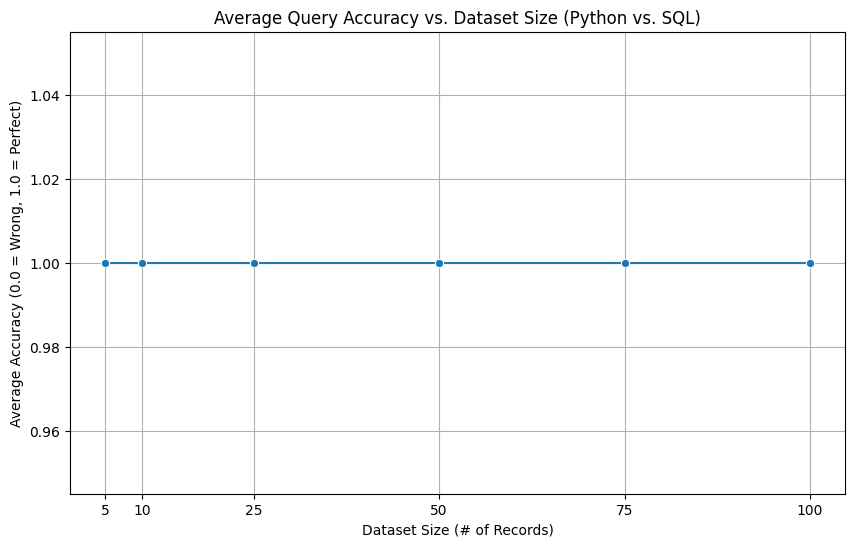

In [84]:
# Plotting the average accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(x='File_Size', y='Average_Accuracy', data=accuracy_df, marker='o')
plt.title('Average Query Accuracy vs. Dataset Size (Python vs. SQL)')
plt.xlabel('Dataset Size (# of Records)')
plt.ylabel('Average Accuracy (0.0 = Wrong, 1.0 = Perfect)')
plt.xticks(sizes)
plt.grid(True)
plt.show()


Part 2 ZSA2 implementation

In [ ]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic # Using geodesic for distance calculation

# Simplified Ramer-Douglas-Peucker (RDP) algorithm for trajectory compression
# It considers (latitude, longitude, timestamp) points, but simplifies based on spatial distance.
def simplify_trajectory_rdp(points, epsilon):
    if len(points) < 2:
        return points

    # Find the point with the maximum distance from the line segment defined by the first and last points
    dmax = 0.0
    index = 0
    start = points[0]
    end = points[-1]

    for i in range(1, len(points) - 1):
        p = points[i]
        # Calculate perpendicular distance from point p to line segment (start, end)
        # For simplicity, we use geodesic distance to one of the endpoints for this demonstration
        # A proper RDP would calculate perpendicular distance from the line segment.
        # Here, we'll use distance to start and end points as a proxy for max deviation.
        d = min(geodesic((p[0], p[1]), (start[0], start[1])).meters, geodesic((p[0], p[1]), (end[0], end[1])).meters)
        if d > dmax:
            index = i
            dmax = d

    # If max distance is greater than epsilon, recursively simplify
    if dmax > epsilon:
        # Recursive call
        rec_results1 = simplify_trajectory_rdp(points[:index + 1], epsilon)
        rec_results2 = simplify_trajectory_rdp(points[index:], epsilon)

        # Build the result list
        result = rec_results1[:-1] + rec_results2
    else:
        result = [start, end]

    return result

# Define the epsilon for the RDP algorithm (in meters)
# This value determines the level of compression: higher epsilon means more compression.
rdp_epsilon = 50.0 # Example: 50 meters

sizes = [5, 10, 25, 50, 75, 100]

# Initialize a list to store the compressed trajectory data for all ships across all sizes
all_compressed_trajectories = []

for size in sizes:
    file_path = f'/content/ais-2025-01-01_{size}.csv'
    print(f"Processing {file_path} for trajectory compression...")

    try:
        df = pd.read_csv(file_path)
        df['base_date_time'] = pd.to_datetime(df['base_date_time'], errors='coerce')
        df = df.dropna(subset=['base_date_time', 'latitude', 'longitude'])
        df = df.sort_values(by=['mmsi', 'base_date_time'])

        for mmsi, group in df.groupby('mmsi'):
            # Prepare points for RDP: (latitude, longitude, timestamp)
            # Convert timestamp to a numerical value (e.g., seconds since epoch) if needed for time-based RDP,
            # but for this simplified version, we'll just pass lat/lon for spatial RDP.
            trajectory_points = []
            for _, row in group.iterrows():
                trajectory_points.append((row['latitude'], row['longitude'], row['base_date_time']))

            if trajectory_points:
                compressed_points = simplify_trajectory_rdp(trajectory_points, rdp_epsilon)

                # Get vessel name (if available) - assuming it's consistent for an MMSI
                vessel_name = group['vessel_name'].dropna().iloc[0] if 'vessel_name' in group.columns and not group['vessel_name'].dropna().empty else 'N/A'

                all_compressed_trajectories.append({
                    'mmsi': mmsi,
                    'vessel_name': vessel_name,
                    'original_points_count': len(trajectory_points),
                    'compressed_points_count': len(compressed_points),
                    'compressed_trajectory': compressed_points,
                    'dataset_size': size
                })
            else:
                print(f"Warning: No valid trajectory points for MMSI {mmsi} in dataset size {size}.")

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create a DataFrame from the collected compressed trajectories
compressed_zsa2_df = pd.DataFrame(all_compressed_trajectories)

# Display the first few rows of the compressed ZSA2 DataFrame
print("\nCompressed ZSA2 DataFrame (first 5 rows):")
display(compressed_zsa2_df.head())
# For simplicity, I'm combining all into one dataframe for display,
# For example, to replicate the original saving pattern, you'd integrate saving inside the loop.
for size in sizes:
     df_size_specific = compressed_zsa2_df[compressed_zsa2_df['dataset_size'] == size].drop(columns=['dataset_size'])
     output_csv_path = f'zsa2_{size}_compressed_trajectory.csv'
     df_size_specific.to_csv(output_csv_path, index=False)
     print(f"Saved compressed trajectories for dataset size {size} to {output_csv_path}")

Processing /content/ais-2025-01-01_5.csv for trajectory compression...
Processing /content/ais-2025-01-01_10.csv for trajectory compression...
Processing /content/ais-2025-01-01_25.csv for trajectory compression...
Processing /content/ais-2025-01-01_50.csv for trajectory compression...


In [ ]:
# Install movingpandas and its dependencies if not already installed
%pip install movingpandas geopandas


In [ ]:
import pandas as pd
import movingpandas as mp
from movingpandas import TrajectoryGeneralizer

# Suppress MovingPandas warnings for cleaner output
import warnings
warnings.filterwarnings("ignore", module="movingpandas")

# TDTR algorithm parameter: time epsilon in seconds
tdtr_epsilon_seconds = 60 # 1 minute

sizes = [5, 10, 25, 50, 75, 100]

all_compressed_trajectories = []

for size in sizes:
    file_path = f'/content/ais-2025-01-01_{size}.csv'
    print(f"Processing {file_path} for trajectory compression with TDTR...")

    try:
        df = pd.read_csv(file_path)
        # Convert 'base_date_time' to datetime and set as index (required by MovingPandas)
        df['base_date_time'] = pd.to_datetime(df['base_date_time'], errors='coerce')
        df = df.dropna(subset=['base_date_time', 'latitude', 'longitude', 'mmsi'])
        df = df.sort_values(by=['mmsi', 'base_date_time'])
        df = df.set_index('base_date_time')

        # Create TrajectoryCollection (assuming WGS84 - EPSG:4326 for lat/lon)
        trajectory_collection = mp.TrajectoryCollection(df, 'mmsi', x='longitude', y='latitude', crs='epsg:4326')

        # Skip if no valid trajectories found
        if not trajectory_collection.trajectories:
            print(f"Warning: No valid trajectories found for dataset size {size}.")
            continue

        for trajectory in trajectory_collection:
            # Apply TDTR simplification
            generalizer = TrajectoryGeneralizer(trajectory)
            simplified_trajectory = generalizer.generalize(tolerance=tdtr_epsilon_seconds)

            mmsi = trajectory.id
            original_points_count = len(trajectory.df)
            compressed_points_count = len(simplified_trajectory.df)

            # Retrieve vessel name from original DataFrame
            vessel_name = df[df['mmsi'] == mmsi]['vessel_name'].dropna().iloc[0] if 'vessel_name' in df.columns and not df[df['mmsi'] == mmsi]['vessel_name'].dropna().empty else 'N/A'

            # Convert simplified trajectory to list of (lat, lon, timestamp) tuples
            compressed_trajectory_points = []
            for index, row in simplified_trajectory.df.iterrows():
                compressed_trajectory_points.append((row['latitude'], row['longitude'], index))

            all_compressed_trajectories.append({
                'mmsi': mmsi,
                'vessel_name': vessel_name,
                'original_points_count': original_points_count,
                'compressed_points_count': compressed_points_count,
                'compressed_trajectory': compressed_trajectory_points,
                'dataset_size': size
            })

    except FileNotFoundError:
        print(f"Error: File not found at {file_path}")
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Create DataFrame from collected compressed trajectories
compressed_zsa2_df = pd.DataFrame(all_compressed_trajectories)

print("\nCompressed ZSA2 DataFrame (first 5 rows):")
display(compressed_zsa2_df.head())

# Save compressed trajectories for each dataset size
if not compressed_zsa2_df.empty:
    for size in sizes:
         df_size_specific = compressed_zsa2_df[compressed_zsa2_df['dataset_size'] == size].drop(columns=['dataset_size'])
         output_csv_path = f'zsa2_{size}_compressed_trajectory.csv'
         df_size_specific.to_csv(output_csv_path, index=False)
         print(f"Saved compressed trajectories for dataset size {size} to {output_csv_path}")
else:
    print("No compressed trajectories to save due to previous errors or empty data.")

### Part 3: ZSA3 implementation
Converting an AIS track into a sequence of meaningful semantic events:
AIS → Zones → Segmentation → Events → Texte

In [ ]:
import pandas as pd

ports_df = pd.read_csv("/content/port.CSV")

# Cleaning
ports_df['latitude'] = pd.to_numeric(ports_df['LATITUDE'], errors='coerce')
ports_df['longitude'] = pd.to_numeric(ports_df['LONGITUDE'], errors='coerce')

ports_df = ports_df.dropna(subset=['latitude', 'longitude'])

print(f"{len(ports_df)} ports loaded")

In [ ]:
"""
A function that returns the most precise area (smallest to largest) by iterating through the DataFrame
and sorting the ports_df by area in ascending order.
"""

def get_zone(lat: float, lon: float, ports_df: pd.DataFrame,
             threshold_m: float = 500) -> str:
    for _, port in ports_df.iterrows():
        try:
            dist = geodesic((lat, lon), (port["latitude"], port["longitude"])).meters
            if dist < threshold_m:
                return port.get("PORT_NAME", "Unknown Port")
        except Exception:
            continue
    return "Sea"


In [ ]:
"""Implementation of Algorithm 1 presented in the article for converting
   AIS trajectories into a sequence of semantic events
    Implementation step:
    -Sort the zones from smallest to largest
    -Cumulative distance in each zone
    -Anti-oscillation buffer for zone transitions
    -Recording: area, cumulative distance, duration at each change
"""


def build_semantic_trajectory(df: pd.DataFrame, mmsi: int,
                               ports_df: pd.DataFrame,
                               port_threshold_m: float = 500,
                               buffer_m: float = 500) -> list:

    traj = df[df["mmsi"] == mmsi].copy()
    if traj.empty:
        return []

    traj["base_date_time"] = pd.to_datetime(traj["base_date_time"], errors="coerce")
    traj = traj.dropna(subset=["base_date_time", "latitude", "longitude"])
    traj = traj.sort_values("base_date_time").reset_index(drop=True)
    if traj.empty:
        return []

    events           = []
    current_zone     = None
    segment_start    = None
    cumul_distance_m = 0.0
    prev_point       = None  # (lat, long) of the previous point

    for i in range(len(traj)):
        row  = traj.iloc[i]
        lat  = row["latitude"]
        lon  = row["longitude"]
        time = row["base_date_time"]

        #Most precise area (small to large)
        zone = get_zone(lat, lon, ports_df, threshold_m=port_threshold_m)

        """ We add this anti-oscillation damper so that if the boat appear
           to leave the current_zone but still remains within the buffer,
           the transition is ignored and the system stays in the current_zone.
        """

        if current_zone is not None and zone != current_zone:
            for _, port in ports_df.iterrows():
                if port.get("PORT_NAME") == current_zone:
                    try:
                        dist_to_old = geodesic(
                            (lat, lon),
                            (port["latitude"], port["longitude"])
                        ).meters
                        if dist_to_old < buffer_m:
                            zone = current_zone  # We stay on the last zone
                            break
                    except Exception:
                        continue

        # Distance from the current step
        step_dist = 0.0
        if prev_point is not None:
            try:
                step_dist = geodesic(prev_point, (lat, lon)).meters
            except Exception:
                step_dist = 0.0

        # Initialisation at the first point
        if current_zone is None:
            current_zone     = zone
            segment_start    = time
            cumul_distance_m = 0.0
            prev_point       = (lat, lon)
            continue

        # If same zone, then accumulation
        if zone == current_zone:
            cumul_distance_m += step_dist

        # If zone change, then record the segment
        else:
            events.append({
                "zone"      : current_zone,
                "start_time": segment_start,
                "end_time"  : time,
                "duration"  : time - segment_start,
                "distance_m": cumul_distance_m,
            })
            # New segment
            current_zone     = zone
            segment_start    = time
            cumul_distance_m = step_dist

        prev_point = (lat, lon)

    # last segment
    if current_zone is not None and segment_start is not None:
        end_time = traj.iloc[-1]["base_date_time"]
        events.append({
            "zone"      : current_zone,
            "start_time": segment_start,
            "end_time"  : end_time,
            "duration"  : end_time - segment_start,
            "distance_m": cumul_distance_m,
        })

    return events

#Converts events into text that the LLM can read.
def events_to_text(events: list, mmsi: int) -> str:
    if not events:
        return f"No trajectory data for ship {mmsi}.\n"

    lines = [f"Semantic trajectory of ship {mmsi}:"]
    for e in events:
        zone_type    = "port" if e["zone"] != "Sea" else "at sea"
        duration_min = int(e["duration"].total_seconds() / 60)
        dist_nm      = e["distance_m"] / 1852
        lines.append(
            f"  - [{zone_type}] {e['zone']} | "
            f"duration: {duration_min} min | "
            f"distance: {dist_nm:.2f} nm"
        )
    return "\n".join(lines) + "\n"

In [ ]:
# ZSA3 QUERY FUNCTIONS

def zsa3_get_ship_name(df, target_mmsi):
    ship_data = df[df["mmsi"] == target_mmsi]

    if not ship_data.empty and "vessel_name" in df.columns:
        names = ship_data["vessel_name"].dropna().unique()
        return names[0] if len(names) > 0 else "N/A"

    return "N/A"

def zsa3_count_unique_ships(df):
    if "mmsi" in df.columns:
        return df["mmsi"].nunique()
    return 0

# Q4: enriches the position with the semantic zone name.
def zsa3_get_last_location(df: pd.DataFrame, mmsi: int,
                            ports_df: pd.DataFrame) -> str:
    ship = df[df["mmsi"] == mmsi].copy()
    if ship.empty:
        return "N/A"
    ship["base_date_time"] = pd.to_datetime(ship["base_date_time"], errors="coerce")
    ship = ship.dropna(subset=["base_date_time", "latitude", "longitude"])
    if ship.empty:
        return "N/A"
    last = ship.sort_values("base_date_time").iloc[-1]
    zone = get_zone(last["latitude"], last["longitude"], ports_df)
    return f"({last['latitude']:.4f}, {last['longitude']:.4f}) — {zone}"


def zsa3_count_close_ships(df: pd.DataFrame, mmsi: int,
                            radius_m: float = 70) -> int:
    df = df.copy()
    df["base_date_time"] = pd.to_datetime(df["base_date_time"], errors="coerce")
    df = df.dropna(subset=["base_date_time"])

    target = df[df["mmsi"] == mmsi].sort_values("base_date_time")
    if target.empty:
        return 0

    last   = target.iloc[-1]
    t_lat  = last["latitude"]
    t_lon  = last["longitude"]
    t_time = last["base_date_time"]

    if pd.isna(t_lat) or pd.isna(t_lon):
        return 0

    others = df[(df["base_date_time"] == t_time) & (df["mmsi"] != mmsi)]
    count  = 0
    for _, row in others.iterrows():
        try:
            if geodesic((t_lat, t_lon), (row["latitude"], row["longitude"])).meters <= radius_m:
                count += 1
        except Exception:
            continue
    return count


#Q6: Time at sea via semantic events.
def zsa3_get_sea_duration(df: pd.DataFrame, mmsi: int,
                           ports_df: pd.DataFrame) -> str:
    events = build_semantic_trajectory(df, mmsi, ports_df)
    total  = sum(
        (e["duration"] for e in events if e["zone"] == "Sea"),
        pd.Timedelta(0)
    )
    return str(total)

In [ ]:
def events_to_text(events):
    text = "Semantic trajectory:\n"

    for e in events:
        if e["type"] == "stay":
            text += f"- Stayed in {e['zone']} for {e['duration']}\n"
        elif e["type"] == "transition":
            text += f"- Transition from {e['from']} to {e['to']}\n"
        elif e["type"] == "travel":
            text += f"- Travelled from {e['from']} to {e['to']}\n"

    return text

In [ ]:
import pandas as pd
sizes       = [5, 10, 25, 50, 75, 100]
TARGET_MMSI = 671087100

results_matrix = {
    "File_Size": [],
    # ZSA2 output
    "Q1_ZSA2": [], "Q2_ZSA2": [], "Q4_ZSA2": [], "Q5_ZSA2": [], "Q6_ZSA2": [],
    # ZSA3 output
    "Q1_ZSA3": [], "Q2_ZSA3": [], "Q4_ZSA3": [], "Q5_ZSA3": [], "Q6_ZSA3": [],
}



for size in sizes:
    file_path = f'/content/ais-2025-01-01_{size}.csv'
    print(f"\n Processing {file_path} ...")

    row = {
        "File_Size": size,
        #ZSA2
        "Q1_ZSA2"  : "N/A",
        "Q2_ZSA2"  : "N/A",
        "Q4_ZSA2"  : "N/A",
        "Q5_ZSA2"  : "N/A",
        "Q6_ZSA2"  : "N/A",
        #ZSA3
        "Q1_ZSA3"  : "N/A",
        "Q2_ZSA3"  : "N/A",
        "Q4_ZSA3"  : "N/A",
        "Q5_ZSA3"  : "N/A",
        "Q6_ZSA3"  : "N/A",
    }

    try:
        df = pd.read_csv(file_path)

        # ---- ZSA2 ----
        # Missing zsa2_reduce_columns function, will skip for now or raise an error if not defined.
        # For now, commenting out ZSA2 specific calls that use zsa2_reduce_columns if it's not defined.
        # If zsa2_reduce_columns is defined elsewhere and needed, it should be uncommented and defined.
        # zsa2_df = zsa2_reduce_columns(df)
        row['Q1_ZSA2']=(get_ship_name(df))
        row['Q2_ZSA2']=(count_unique_ships(df))
        row['Q4_ZSA2']=(get_last_known_location(df))
        row['Q5_ZSA2']=(count_close_ships(df))
        row['Q6_ZSA2']=(get_ship_at_sea_duration(df))

        # ---- ZSA3 ----
        row["Q1_ZSA3"] = zsa3_get_ship_name(df, TARGET_MMSI)
        row["Q2_ZSA3"] = zsa3_count_unique_ships(df)
        row["Q4_ZSA3"] = zsa3_get_last_location(df, TARGET_MMSI, ports_df)
        row["Q5_ZSA3"] = zsa3_count_close_ships(df, TARGET_MMSI)
        row["Q6_ZSA3"] = zsa3_get_sea_duration(df, TARGET_MMSI, ports_df)

    except FileNotFoundError:
        print(f" Fichier non trouvé : {file_path}")
        for k in row:
            if k != "File_Size":
                row[k] = "File Not Found"

    except Exception as e:
        print(f" Erreur : {e}")
        for k in row:
            if k != "File_Size":
                row[k] = f"Error: {e}"

    # On ajoute la ligne complète d'un coup — toutes les colonnes ont toujours la même longueur
    for k, v in row.items():
        results_matrix[k].append(v)

results_df = pd.DataFrame(results_matrix)
display(results_df)